# Objective
The objective of this project is to build multiple regression models to predict housing prices based on relevant features of the dataset.

## Understanding the data

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [34]:
df = pd.read_csv('Housing.csv')

In [35]:
df.shape

(545, 13)

In [36]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [37]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'parking'}>]], dtype=object)

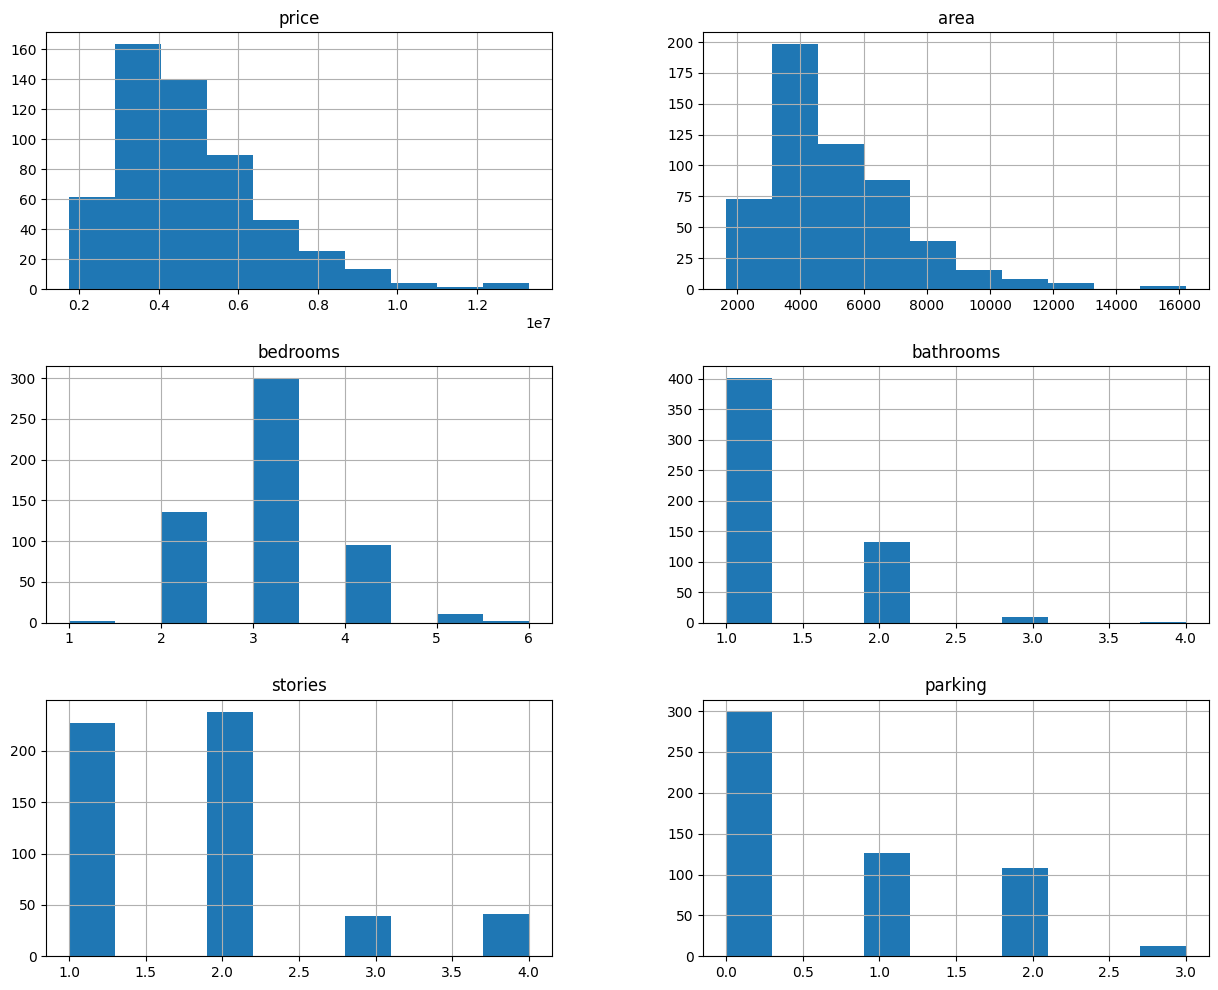

In [39]:
df.hist(figsize=(15, 12))

In [40]:
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
num_cols = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price']]

In [41]:
num_cols.corr()

,area,bedrooms,bathrooms,stories,parking,price
area,1.000000,0.151858,0.193820,0.083996,0.352980,0.535997
bedrooms,0.151858,1.000000,0.373930,0.408564,0.139270,0.366494
bathrooms,0.193820,0.373930,1.000000,0.326165,0.177496,0.517545
stories,0.083996,0.408564,0.326165,1.000000,0.045547,0.420712
parking,0.352980,0.139270,0.177496,0.045547,1.000000,0.384394
price,0.535997,0.366494,0.517545,0.420712,0.384394,1.000000


<Axes: >

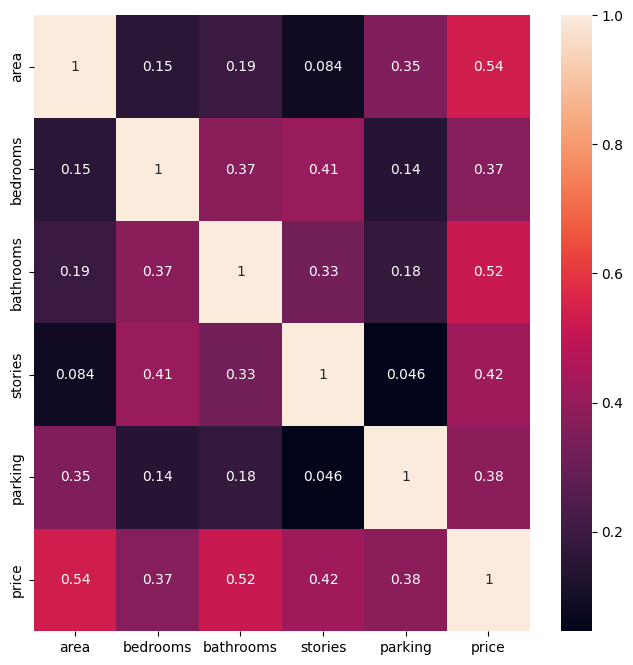

In [42]:
plt.figure(figsize=(8, 8))
sns.heatmap(num_cols.corr(), annot=True)

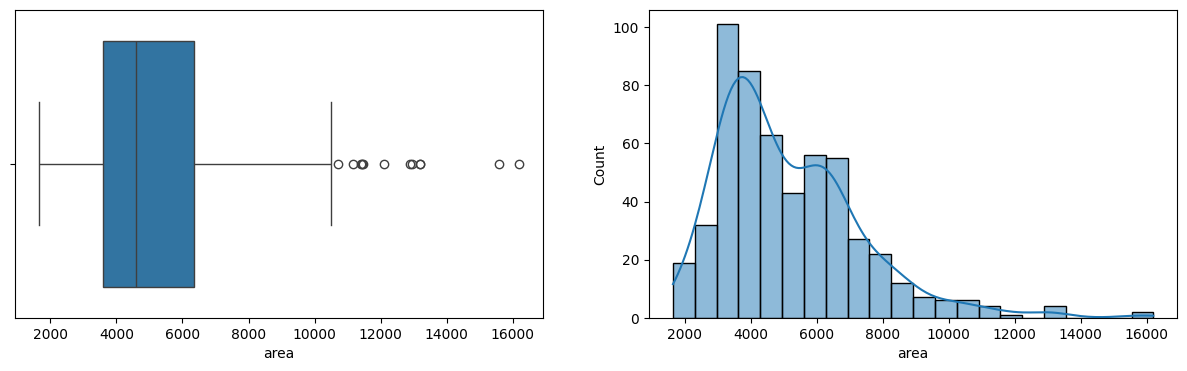

In [43]:
plt.figure(figsize=(15, 4))
plt.subplot(1,2,1)
sns.boxplot(x='area', data = df)
plt.subplot(1,2,2)
sns.histplot(x = 'area', kde=True, data = df) 
plt.show()

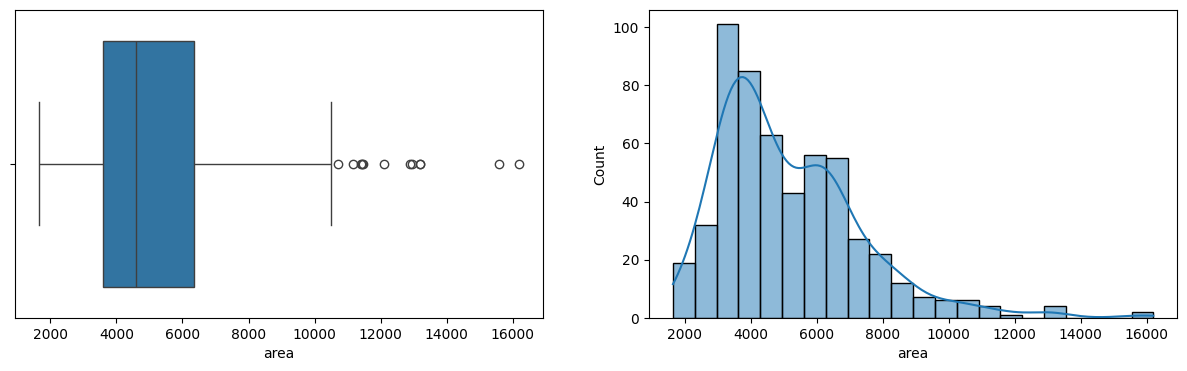

In [44]:
plt.figure(figsize=(15, 4))
plt.subplot(1,2,1)
sns.boxplot(x='area', data = df)
plt.subplot(1,2,2)
sns.histplot(x = 'area', kde=True, data = df) 
plt.show()

## Train Test Split

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X = df.drop(columns='price')
y = df['price']

In [47]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2)

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

trns = ColumnTransformer(
    transformers = [
        ('ss', StandardScaler(), ['area']),
        ('ohe', OneHotEncoder(drop='first'), cat_cols)
    ], remainder='passthrough'
)

In [49]:
train_X_transformed = trns.fit_transform(X_train)
test_X_transformed = trns.transform(X_test)
col_names = trns.get_feature_names_out()

In [50]:
train_X_transformed.shape

(436, 13)

In [51]:
X_train_df = pd.DataFrame(train_X_transformed, columns=col_names)
X_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   ss__area                              436 non-null    float64
 1   ohe__mainroad_yes                     436 non-null    float64
 2   ohe__guestroom_yes                    436 non-null    float64
 3   ohe__basement_yes                     436 non-null    float64
 4   ohe__hotwaterheating_yes              436 non-null    float64
 5   ohe__airconditioning_yes              436 non-null    float64
 6   ohe__prefarea_yes                     436 non-null    float64
 7   ohe__furnishingstatus_semi-furnished  436 non-null    float64
 8   ohe__furnishingstatus_unfurnished     436 non-null    float64
 9   remainder__bedrooms                   436 non-null    float64
 10  remainder__bathrooms                  436 non-null    float64
 11  remainder__stories            

<Axes: >

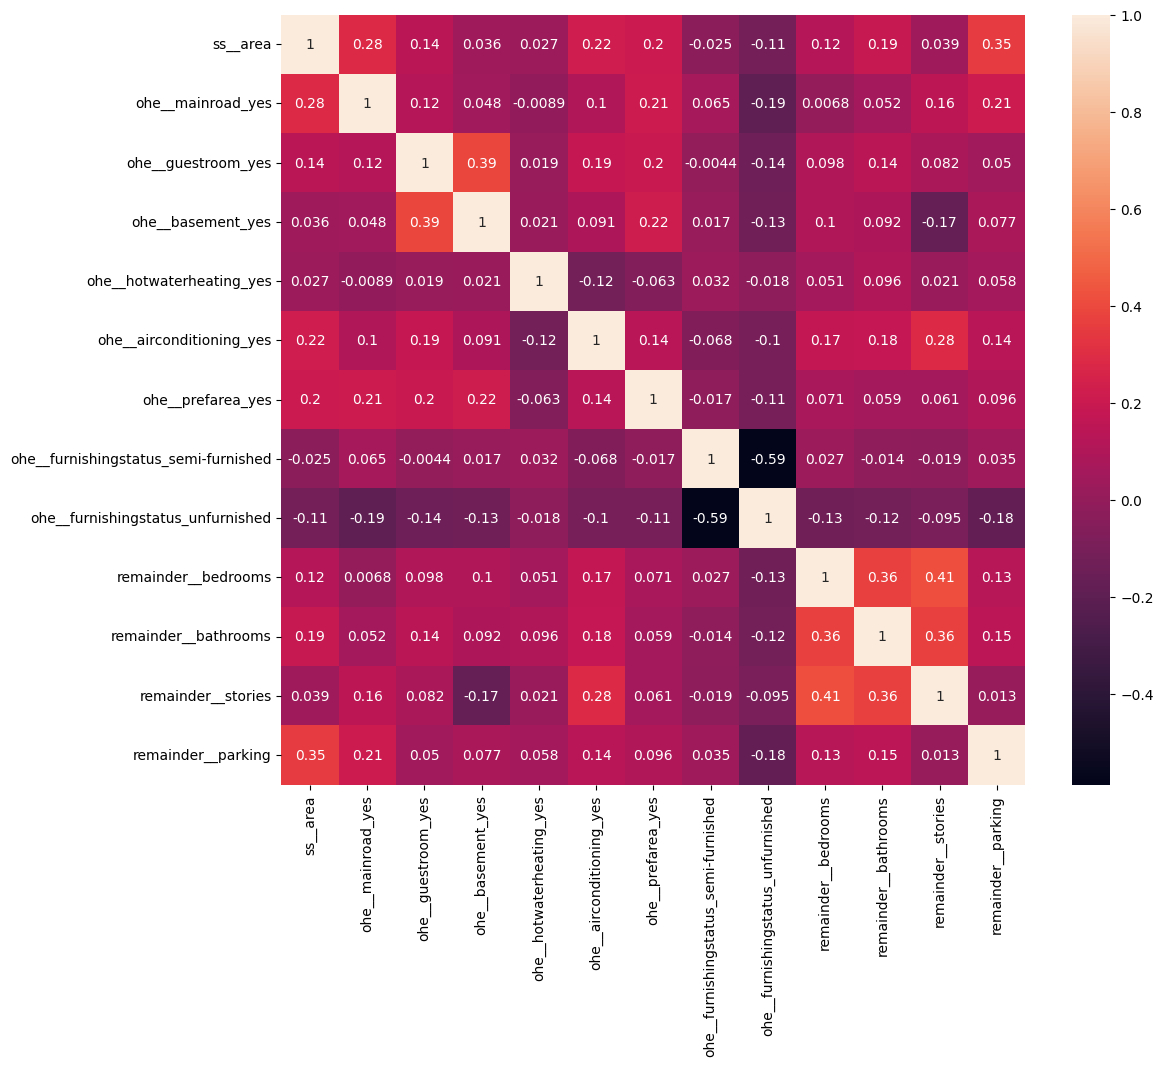

In [52]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_df.corr(), annot = True)

In [53]:
train_X_transformed

array([[-0.3417617 ,  1.        ,  0.        , ...,  1.        ,
         1.        ,  1.        ],
       [ 0.40434434,  1.        ,  0.        , ...,  2.        ,
         4.        ,  0.        ],
       [ 0.60952351,  1.        ,  0.        , ...,  1.        ,
         1.        ,  3.        ],
       ...,
       [-1.48423659,  1.        ,  0.        , ...,  2.        ,
         2.        ,  0.        ],
       [-0.24849845,  1.        ,  0.        , ...,  1.        ,
         2.        ,  0.        ],
       [-0.49144923,  1.        ,  0.        , ...,  1.        ,
         3.        ,  0.        ]], shape=(436, 13))

## Model Training & Evaluation

### Linear Regression

In [54]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_X_transformed, Y_train)
y_pred = lr.predict(test_X_transformed)

In [67]:
from sklearn.metrics import r2_score, mean_squared_error

print('R2 Score: ', r2_score(Y_test, y_pred))
print('Root Mean Squared Error: ', np.sqrt(mean_squared_error(Y_test, y_pred)))

R2 Score:  0.6255285167697788
Root Mean Squared Error:  1221605.982459581


### KNN Regressor

In [56]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor()
knr.fit(train_X_transformed, Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [68]:
from sklearn.metrics import r2_score, mean_squared_error

print('R2 Score: ', r2_score(Y_test, y_pred))
print('Root Mean Squared Error: ', np.sqrt(mean_squared_error(Y_test, y_pred)))

R2 Score:  0.6255285167697788
Root Mean Squared Error:  1221605.982459581


### Decision Tree Regressor

In [58]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [79]:
for i in range(1, 15):
    regressor = DecisionTreeRegressor(max_depth=i, random_state=42)
    regressor.fit(train_X_transformed, Y_train)
    y_pred = regressor.predict(test_X_transformed)
    print('Depth ' , i, '\nR2:', r2_score(Y_test, y_pred), '\nRMSE: ', np.sqrt(mean_squared_error(Y_test, y_pred)))

Depth  1 
R2: 0.33522603092494285 
RMSE:  1627641.5881001928
Depth  2 
R2: 0.449730717606063 
RMSE:  1480844.342245263
Depth  3 
R2: 0.44634904883386706 
RMSE:  1485387.6222907535
Depth  4 
R2: 0.4075740380992525 
RMSE:  1536522.119369747
Depth  5 
R2: 0.36698861915855996 
RMSE:  1588281.7092051213
Depth  6 
R2: 0.35333243235438516 
RMSE:  1605322.5844215725
Depth  7 
R2: 0.3124044922189131 
RMSE:  1655344.1211271673
Depth  8 
R2: 0.2557812538847819 
RMSE:  1722154.3701674975
Depth  9 
R2: 0.23087300199788963 
RMSE:  1750736.5702112115
Depth  10 
R2: 0.2635450615737136 
RMSE:  1713147.9260123274
Depth  11 
R2: 0.15850140106336963 
RMSE:  1831253.5266058468
Depth  12 
R2: 0.1392318914820525 
RMSE:  1852101.8239944275
Depth  13 
R2: 0.2322888710531713 
RMSE:  1749124.3815935417
Depth  14 
R2: 0.16121377612553012 
RMSE:  1828299.8345867812


### Ridge Regression

In [81]:
from sklearn.linear_model import Ridge

for i in range(1, 10):
    ridge = Ridge(alpha=i)
    ridge.fit(train_X_transformed, Y_train)
    y_pred = ridge.predict(test_X_transformed)
    print('Alpha ' , i, '\nR2:', r2_score(Y_test, y_pred), '\nRMSE: ', np.sqrt(mean_squared_error(Y_test, y_pred)))

Alpha  1 
R2: 0.6691621559781421 
RMSE:  1148231.2607999889
Alpha  2 
R2: 0.6676170898764556 
RMSE:  1150909.3502738231
Alpha  3 
R2: 0.6661419251765952 
RMSE:  1153460.476117501
Alpha  4 
R2: 0.6647293756551477 
RMSE:  1155898.039253053
Alpha  5 
R2: 0.6633730273954408 
RMSE:  1158233.7909304986
Alpha  6 
R2: 0.6620672566692829 
RMSE:  1160478.002040653
Alpha  7 
R2: 0.6608071397283262 
RMSE:  1162639.641193774
Alpha  8 
R2: 0.6595883650663885 
RMSE:  1164726.54411775
Alpha  9 
R2: 0.6584071528619839 
RMSE:  1166745.5670491387


### Lasso Regression

In [61]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=53000)
lasso.fit(train_X_transformed, Y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",53000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [82]:
y_pred = lasso.predict(test_X_transformed)

print('R2 Score: ', r2_score(Y_test, y_pred))
print('Root Mean Squared Error: ', np.sqrt(mean_squared_error(Y_test, y_pred)))

R2 Score:  0.6255285167697788
Root Mean Squared Error:  1221605.982459581


In [83]:
from sklearn.model_selection import cross_val_score

models = [lasso, ridge, lr, knr, regressor]

for i in models:
    scores = cross_val_score(
        i,
        train_X_transformed,
        Y_train,
        cv=10,
        scoring='r2'
    )
    print(f"Average r2 of {i} is: {scores.mean():.2f}")

Average r2 of Lasso(alpha=53000) is: 0.60
Average r2 of Ridge(alpha=9) is: 0.62
Average r2 of LinearRegression() is: 0.62
Average r2 of KNeighborsRegressor() is: 0.58
Average r2 of DecisionTreeRegressor(max_depth=14, random_state=42) is: 0.28


In [84]:
from sklearn.metrics import mean_squared_error

models = [lasso, ridge, lr, knr, regressor]

for i in models:
    scores = cross_val_score(
        i,
        train_X_transformed,
        Y_train,
        cv=10,
        scoring='neg_mean_squared_error'
    )
    print(f"RMSE of {i}: {np.sqrt(-scores.mean()):.2f}")


RMSE of Lasso(alpha=53000): 1112743.88
RMSE of Ridge(alpha=9): 1080589.55
RMSE of LinearRegression(): 1083923.33
RMSE of KNeighborsRegressor(): 1139331.13
RMSE of DecisionTreeRegressor(max_depth=14, random_state=42): 1491222.27
